In [32]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu


In [4]:
# Define functions
def load_adjacency_p_values(input_dir: Path):
    """Load adjacency permutation test p-values for each ROI.

    Parameters:
        input_dir : Path
            Directory containing APT permutation test

    Returns:
        dict
            {roi_name: dataframe}

    """
    results = {}

    for file in sorted(input_dir.glob("adjacency_permutation_test_p_values_*.csv")):
        roi = file.stem.removeprefix("adjacency_permutation_test_p_values_")
        df = pd.read_csv(file, index_col=0)

        results[roi] = df

    return results


def make_clustermap(
    cell_type, celltype_dict, meta, meta_cols, cmap="vlag", fig_path=None
):
    """Make clustermap of APT scores for a given cell type.

    Args:
        cell_type (str): Cell type to plot
        celltype_dict (dict): Dictionary of dataframes for cell type across conditions
        meta (pd.DataFrame): Metadata dataframe with ROI information
        meta_cols (list): List of metadata columns to include in annotations
        cmap (str): Colormap for heatmap
        fig_path (Path): Path to save figure

    Returns:
        sns.ClusterGrid: ClusterGrid object containing the clustermap

    """
    safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")

    # Build matrix
    celltype_df = pd.DataFrame(celltype_dict[cell_type])
    heatmap_df = celltype_df.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Validate metadata
    for col in meta_cols:
        if col not in meta.columns:
            raise ValueError(f"Missing metadata column: {col}")

    meta_subset = meta.loc[heatmap_df.columns, meta_cols]

    # Build color annotations + store palettes
    col_colors = pd.DataFrame(index=heatmap_df.columns)
    palettes = {}

    for col in meta_cols:
        # Unique values
        unique_vals = meta_subset[col].unique()

        # Number of unique values
        length = len(unique_vals)

        palette = dict(zip(unique_vals, sns.color_palette("husl", length)))

        palettes[col] = palette
        col_colors[col] = meta_subset[col].map(palette)

    # Plot
    g = sns.clustermap(
        heatmap_df,
        cmap=cmap,
        center=0,
        linewidths=0.5,
        figsize=(12, 8),
        col_colors=col_colors,
        row_cluster=True,
        col_cluster=False,
        xticklabels=True,
        yticklabels=True,
    )

    g.figure.suptitle(f"{cell_type} - APT SES (p-val filtered)", y=1.02)

    # Build legend (outside plot)
    legend_handles = []

    for col in meta_cols:
        for level, color in palettes[col].items():
            legend_handles.append(Patch(facecolor=color, label=f"{col}: {level}"))

    g.ax_heatmap.legend(
        handles=legend_handles,
        title="Metadata",
        bbox_to_anchor=(1.6, 1),
        loc="upper left",
        frameon=False,
    )

    # Save figure
    plt.savefig(
        fig_path / f"{safe_cell_type}_APT_SES_p_val_filtered.pdf",
        bbox_inches="tight",
    )
    plt.close()


In [79]:
# Base project path
base_path = Path(
    "/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/"
)

# Input
input_dir = base_path / "output" / "muspan" / "adjacency_permutation_test_results"

# Output directories
outpath = base_path / "output" / "muspan" / "APT_plots"
heatmap_path = outpath / "heatmaps_zscores"
barplot_path_zscore = outpath / "barplots_zscores"

# Create directories
for path in [outpath, heatmap_path, barplot_path_zscore]:
    path.mkdir(parents=True, exist_ok=True)

# Plot heatmap of z-scores for each condition
cmap_rnb = sns.color_palette("vlag", as_cmap=True)
diagnosis_palette = {
    "IPF": "#6A7FB5",  # slate blue
    "LUNG_CANCER": "#B07D4A",  # warm tan
    "COPD": "#7EB0B8",  # dusty teal
    "HEALTHY": "#8EA882",  # sage
    "NO_CRD": "#A67B8A",  # muted rose
}

# Load metadata
meta = pd.read_csv(
    base_path / "data/meta/STx_meta_analysis_only_cleaned.csv", index_col=0
)

# Import adjacency permutation test
ROI_APT_dict = load_adjacency_p_values(input_dir)  #

# Get list of all cell types across conditions
cell_type_list = next(iter(ROI_APT_dict.values())).index.tolist()

# Make empty dict to store combined dataframes for each cell type
celltype_dict = {}

# Combine dataframes for each cell type across conditions
for cell_type in cell_type_list:
    combined = pd.DataFrame(
        {
            condition: df.loc[cell_type]
            if cell_type in df.index
            else pd.Series(float("nan"), index=df.columns)
            for condition, df in ROI_APT_dict.items()
        }
    )

    celltype_dict[cell_type] = combined


In [80]:
# # Drop ROI names from celltype_dict
# ROI_to_drop = ["MICA_III_319_315_311", "MICA_III_325_337_379"]
# for cell_type in cell_type_list:
#     celltype_dict[cell_type] = celltype_dict[cell_type].drop(columns=ROI_to_drop)

# Remove COPD and MICA samples to focus on IPF vs PM08 comparison from celltype_dict
for cell_type in cell_type_list:
    celltype_dict[cell_type] = celltype_dict[cell_type].drop(
        columns=[col for col in celltype_dict[cell_type].columns if "COPD" in col]
        + [col for col in celltype_dict[cell_type].columns if "MICA" in col] + [col for col in celltype_dict[cell_type].columns if "PM08_159" in col]
    )

In [12]:
celltype_dict["Adventitial fibroblasts"].columns

Index(['IPF_RBH_01', 'IPF_RBH_02', 'IPF_RBH_03', 'IPF_RBH_04', 'IPF_RBH_06',
       'IPF_RBH_14', 'IPF_RBH_15', 'IPF_RBH_16', 'IPF_RBH_18', 'IPF_RBH_19',
       'PM08_162', 'PM08_163', 'PM08_164', 'PM08_167', 'PM08_169'],
      dtype='object')

In [82]:
# Data
meta_column = "diagnosis"
cmap = sns.color_palette("vlag", as_cmap=True)


all_cell_types_list = list(celltype_dict.keys())

# Desired diagnosis order
diagnosis_order = ["LUNG_CANCER", "IPF"]
condition_1 = "PM08"
condition_2 = "IPF"

# Significance level for Mann-Whitney U test
alpha_level = 0.05

# Figure dir
fig_dir = outpath / f"{condition_1}_vs_{condition_2}"
fig_dir.mkdir(parents=True, exist_ok=True)


/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_90986/1945864421.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""])
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_90986/1945864421.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""])
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_90986/1945864421.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""])
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_90986/1945864421.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""])


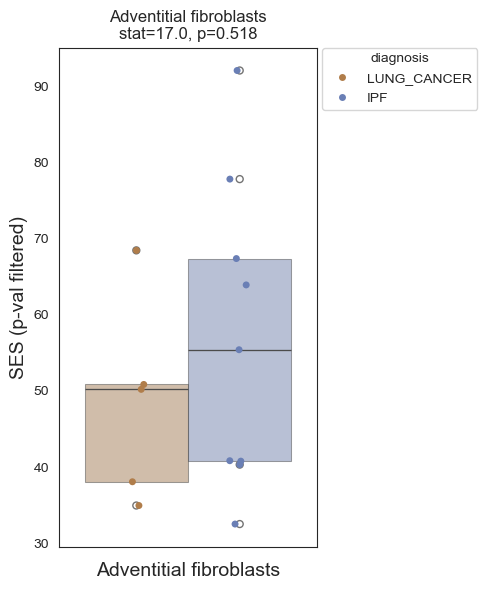

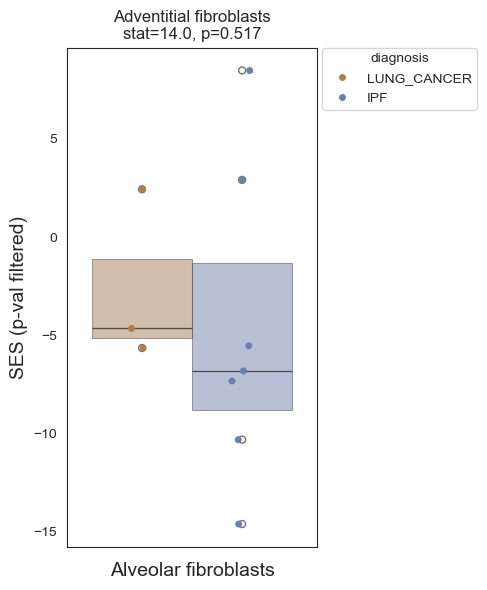

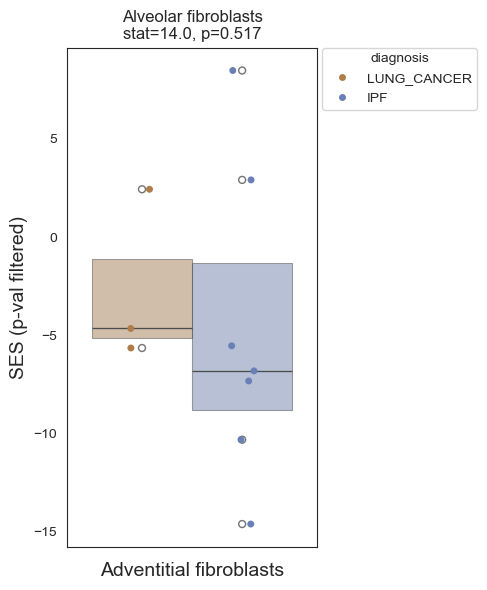

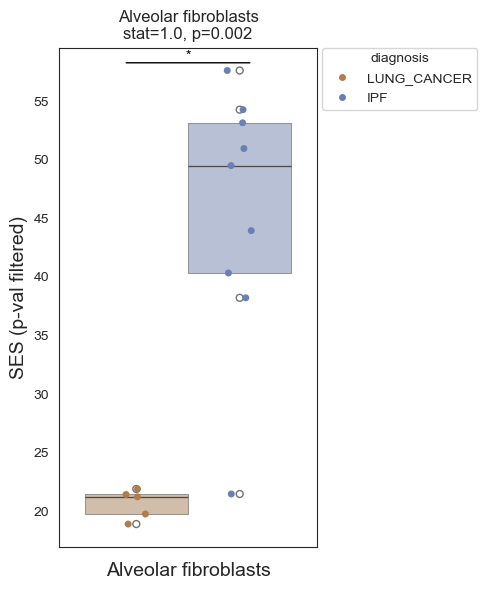

In [ ]:
for celltype_of_interest in all_cell_types_list[:2]:
    # Sanitize cell type name for file paths
    safe_cell_type = celltype_of_interest.replace("/", "_").replace(" ", "_")
    
    # HEATMAP OF APT Z-SCORES FOR ALL NEIGHBORING CELL TYPES
    # Heatmap data
    celltype_df = pd.DataFrame(celltype_dict[celltype_of_interest])
    heatmap_df = celltype_df.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Metadata aligned to heatmap columns
    meta_subset = meta.loc[heatmap_df.columns, meta_column]

    # Order samples by diagnosis
    ordered_columns = (
        meta_subset.map(
            lambda x: diagnosis_order.index(x)
            if x in diagnosis_order
            else len(diagnosis_order)
        )
        .sort_values()
        .index
    )

    heatmap_df = heatmap_df[ordered_columns]
    meta_subset = meta_subset.loc[ordered_columns]
    
    # Column annotation colors
    col_colors = meta_subset.map(diagnosis_palette)

    # Plot
    g = sns.clustermap(
        heatmap_df,
        cmap=cmap,
        center=0,
        linewidths=0.5,
        figsize=(10, 8),
        col_colors=col_colors,
        xticklabels=True,
        yticklabels=True,
        col_cluster=False,
    )

    g.figure.suptitle(
        f"{celltype_of_interest} - APT SES (p-val filtered)", y=0.85
    )


    # Set cbar label and move it to the right of the plot
    g.ax_cbar.set_position([-0.07, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
    g.ax_cbar.set_ylabel("SES (p-val filtered)", rotation=90, labelpad=-60)

    # Legend
    legend_handles = [
        Patch(facecolor=diagnosis_palette[diag], label=diag)
        for diag in diagnosis_order
        if diag in diagnosis_palette
    ]

    g.ax_heatmap.legend(
        handles=legend_handles,
        title="Diagnosis",
        bbox_to_anchor=(1.5, 1),
        loc="upper left",
        frameon=False,
    )

    plt.savefig(
        fig_dir / f"{safe_cell_type}_APT_SES_p_val_filtered_heatmap.pdf",
        bbox_inches="tight",
    )
    plt.close()

    # BOX PLOTS OF APT Z-SCORES FOR EACH NEIGHBORING CELL TYPE, FACETTED BY DIAGNOSIS
    # Get list of all cell types
    all_cell_types_list = list(celltype_dict.keys())
    for cell_type_2_of_interest in all_cell_types_list[:2]:
        # Make cell_type_2_of_interest safe for file paths
        safe_cell_type_2 = cell_type_2_of_interest.replace("/", "_").replace(" ", "_")
        
        if meta_column not in meta.columns:
            raise ValueError(f"Metadata column '{meta_column}' not found in meta dataframe")

        # make directory for this cell type if it doesn't exist
        celltype_dir = fig_dir / safe_cell_type
        celltype_dir.mkdir(parents=True, exist_ok=True)

        # Extract the dataframe for this cell type across conditions
        celltype_df = pd.DataFrame(celltype_dict[celltype_of_interest])

        # SUBSET ON CELL TYPE 2 OF INTEREST
        celltype_df = celltype_df.loc[[cell_type_2_of_interest]]

        # Makr into dataframe
        df_groups = pd.DataFrame(celltype_df)

        # Get both groups of data for Mann-Whitney U test
        group_1_data = df_groups.loc[:, df_groups.columns.str.contains(condition_1)].to_numpy().ravel()
        group_2_data = df_groups.loc[:, df_groups.columns.str.contains(condition_2)].to_numpy().ravel()

        group_1_data = group_1_data.astype(float)
        group_2_data = group_2_data.astype(float)

        group_1_data = group_1_data[~np.isnan(group_1_data)]
        group_2_data = group_2_data[~np.isnan(group_2_data)]

        stat, p_value = mannwhitneyu(group_1_data, group_2_data)

        # Calculate statistics
        stat, p_value = mannwhitneyu(group_1_data, group_2_data)

        # Transpose and melt the dataframe for plotting
        plot_df = celltype_df.transpose().reset_index().rename(columns={"index": "ROI"})

        plot_df = plot_df.melt(
            id_vars="ROI", var_name="Neighbor Cell Type", value_name="SES (p-val filtered)"
        )

        # # Add condition column by extracting from ROI name
        plot_df = plot_df.merge(meta, left_on="ROI", right_index=True)

        # Drop NaN values before plotting
        plot_df = plot_df.dropna(subset=["SES (p-val filtered)"])

        # Set order of conditions for plotting if diagnosis column is present
        if "diagnosis" in plot_df.columns:
            plot_df["diagnosis"] = pd.Categorical(
                plot_df["diagnosis"],
                categories=diagnosis_order,
                ordered=True,
            )

        sns.set_style("white")
        fig, ax = plt.subplots(figsize=(5, 6))

        sns.stripplot(
            data=plot_df,
            x="Neighbor Cell Type",
            y="SES (p-val filtered)",
            hue=meta_column,
            dodge=True,
            alpha=1,
            palette=diagnosis_palette,
            ax=ax,
        )

        sns.boxenplot(
            data=plot_df,
            x="Neighbor Cell Type",
            y="SES (p-val filtered)",
            hue=meta_column,
            dodge=True,
            alpha=0.5,
            palette=diagnosis_palette,
            ax=ax,
        )

        # Remove duplicate legends
        handles, labels = ax.get_legend_handles_labels()
        n = len(plot_df[meta_column].unique())

        ax.legend(
            handles[:n],
            labels[:n],
            title=meta_column,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
        )

        ax.set_title(
            f"{celltype_of_interest}\nstat={stat}, p={p_value:.3f}",
            fontsize=14
        )

        #ax.set_title(f"{celltype_of_interest} - Neighborhood Enrichment Z-scores")
        ax.set_xticklabels([""])
        ax.set_xlabel(cell_type_2_of_interest, fontsize=14)
        ax.set_ylabel("SES (p-val filtered)", fontsize=14)

        # add significance annotation if p-value is below alpha level and set axis color to red
        if p_value < alpha_level:
            # add significance annotation
            ax.annotate('', xy=(0.25, 0.97), xycoords='axes fraction', xytext=(0.75, 0.97),
                        textcoords='axes fraction', arrowprops=dict(arrowstyle='-', color='k', lw=1))
            ax.text(0.5, 0.972, f'*', ha='center', va='bottom', transform=ax.transAxes, color='k')


        plt.tight_layout()
        plt.savefig(
            celltype_dir / f"{safe_cell_type}_and_{safe_cell_type_2}_{meta_column}_SES_p_val_filtered.pdf"
        )


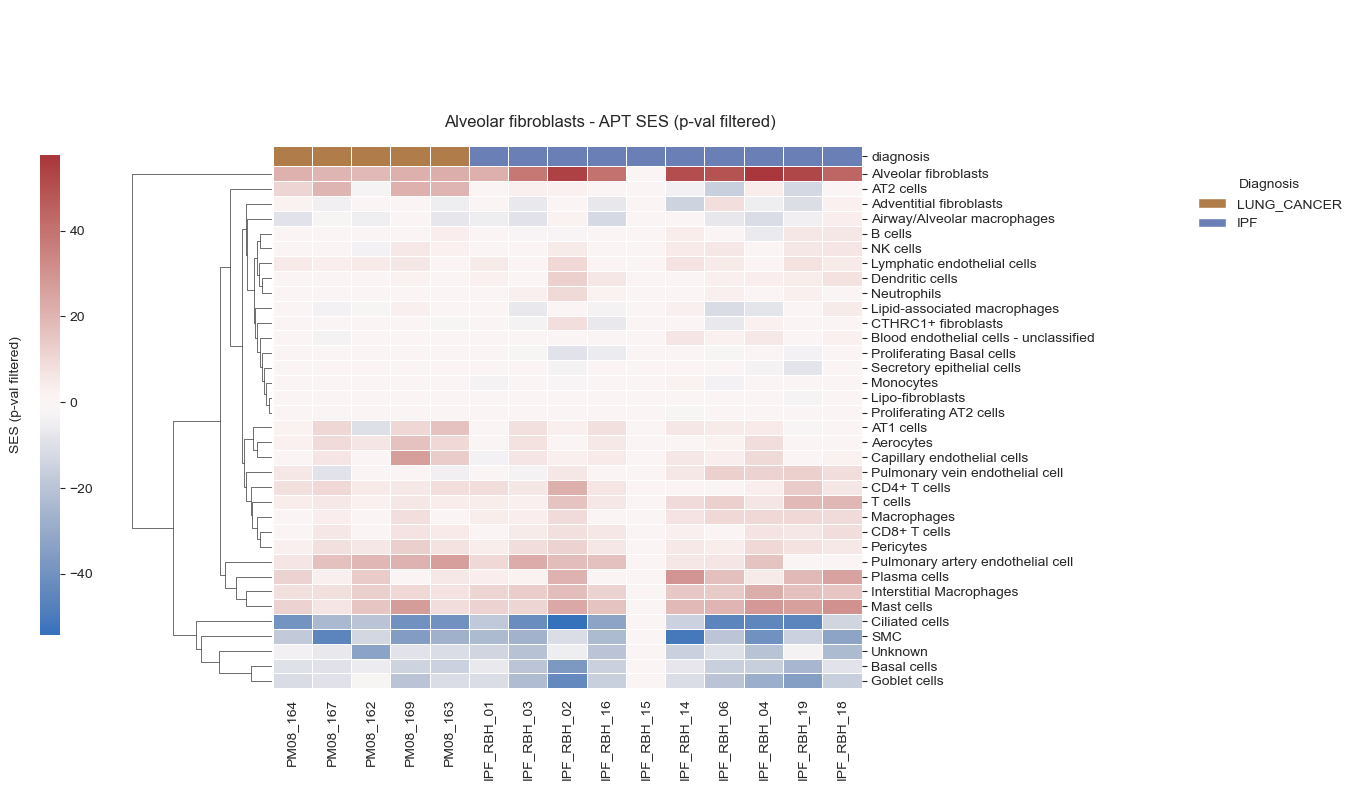

In [90]:
# Plot
g = sns.clustermap(
    heatmap_df,
    cmap=cmap,
    center=0,
    linewidths=0.5,
    figsize=(10, 8),
    col_colors=col_colors,
    xticklabels=True,
    yticklabels=True,
    col_cluster=False,
)

g.figure.suptitle(
    f"{celltype_of_interest} - APT SES (p-val filtered)", y=0.85
)


# Set cbar label and move it to the right of the plot
g.ax_cbar.set_position([-0.07, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
g.ax_cbar.set_ylabel("SES (p-val filtered)", rotation=90, labelpad=-60)

# Legend
legend_handles = [
    Patch(facecolor=diagnosis_palette[diag], label=diag)
    for diag in diagnosis_order
    if diag in diagnosis_palette
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Diagnosis",
    bbox_to_anchor=(1.55, 1),
    loc="upper left",
    frameon=False,
)